# Data Cleaning & EDA

This notebook inspects the already-downloaded xBD data: it audits the inherited split index, scans every post-disaster label file once, explores the **training** split to inform modelling choices, runs cleaning diagnostics, applies the resulting exclusion rules, and extracts the pre/post building patches used for training. It also characterises the **wildfire out-of-distribution (OOD)** test domain.

Ensure that `scripts/prepare_splits.py` has already been run.

All tables and figures are written to `results/eda/`. The cleaned patch arrays consumed by `train_scratch_cnn.ipynb` and `pretrained_resnet18_train.ipynb` are written to `work-pretrained/patches/`.

## 1 · Configuration and imports

One cell holds every path and constant. `results/eda/cache/` stores the label scan so re-runs skip the slow pass.

In [1]:
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import json
import random
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

warnings.filterwarnings('ignore', category=UserWarning)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'data').exists():
    REPO_ROOT = Path('..').resolve()
XBD_DIR = REPO_ROOT / 'xbd'
SPLITS_CSV = REPO_ROOT / 'data' / 'splits.csv'
OUTPUT_DIR = REPO_ROOT / 'results' / 'eda'
CACHE_DIR = OUTPUT_DIR / 'cache'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
QC_SAMPLE_SCENES = 500          # post-disaster scenes fully decoded for pixel-level image QC
EXAMPLES_PER_CLASS = 5          # columns in the representative-sample grid
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DAMAGE_CLASSES = ['no-damage', 'minor-damage', 'major-damage', 'destroyed']
DAMAGE_ORDER = DAMAGE_CLASSES + ['un-classified', 'missing']
SHORT = ['none', 'minor', 'major', 'destr']
NAME_TO_IDX = {name: index for index, name in enumerate(DAMAGE_CLASSES)}
SPLIT_ORDER = ['train', 'val', 'test_id', 'test_ood']
CLASS_COLORS = ['#4e79a7', '#59a14f', '#e15759', '#8c564b', '#b0b0b0', '#dddddd']
FIRE_COLOR, NONFIRE_COLOR = '#e15759', '#4e79a7'

# Patch-extraction parameters. PATCH_SIZE/BBOX_PAD/MIN_BBOX_PX are justified against the measured
# bbox distribution in Section 4.4; the rest configure Section 7, which does the actual extraction.
PATCH_SIZE, BBOX_PAD, MIN_BBOX_PX = 64, 10, 8
MIN_BUILDINGS_PER_SCENE = 5     # scene-sampling filter (Section 7.1) — empty scenes waste extraction budget
SCENE_BUDGET = {'train': 800, 'val': 200, 'test_id': 300, 'test_ood': 400}   # scenes extracted per split
EXTRACT_WORKERS = 8             # threads for patch extraction — I/O-bound, PIL releases the GIL while decoding
BLANK_FRAC, WHITE_LVL, BLACK_LVL = 0.98, 250, 6   # a crop this washed-out/blacked-out is rejected as content-free

PATCHES_DIR = REPO_ROOT / 'work-pretrained' / 'patches'   # shared by both training notebooks
PATCHES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False})

print('repository :', REPO_ROOT)
print('xbd        :', XBD_DIR)
print('outputs    :', OUTPUT_DIR)
print('patches    :', PATCHES_DIR)

repository : C:\Users\bhvns\Documents\University of Konstanz\Courses\satellite-disaster-damage-mapping
xbd        : C:\Users\bhvns\Documents\University of Konstanz\Courses\satellite-disaster-damage-mapping\xbd
outputs    : C:\Users\bhvns\Documents\University of Konstanz\Courses\satellite-disaster-damage-mapping\results\eda
patches    : C:\Users\bhvns\Documents\University of Konstanz\Courses\satellite-disaster-damage-mapping\work-pretrained\patches


## 2 · Split index check

Load `data/splits.csv`, resolve every path, and confirm the inherited assignment is internally consistent . Wildfire events are identified here as the events that appear **only** in `test_ood`.

In [2]:
if not SPLITS_CSV.exists():
    raise FileNotFoundError(f'Missing split index: {SPLITS_CSV}')
if not XBD_DIR.exists():
    raise FileNotFoundError(f'Missing xBD directory: {XBD_DIR}')

splits_df = pd.read_csv(SPLITS_CSV)
required_columns = {'name', 'path', 'subdir', 'scene_id', 'disaster', 'kind', 'origin', 'split'}
if missing := required_columns - set(splits_df.columns):
    raise ValueError(f'splits.csv is missing columns: {sorted(missing)}')

splits_df['resolved_path'] = splits_df['path'].astype(str).map(
    lambda value: REPO_ROOT / Path(value.replace('\\', '/')))
splits_df['exists'] = splits_df['resolved_path'].map(Path.exists)

scenes = splits_df.drop_duplicates('scene_id')[['scene_id', 'disaster', 'origin', 'split']].reset_index(drop=True)
FIRE_EVENTS = sorted(event for event, group in scenes.groupby('disaster')
                     if set(group['split']) == {'test_ood'})
scenes['is_fire'] = scenes['disaster'].isin(FIRE_EVENTS)

print(f'indexed files : {len(splits_df):,}  ({splits_df.exists.sum():,} present on disk)')
print(f'scenes        : {len(scenes):,}  across {scenes.disaster.nunique()} disaster events')
print(f'wildfire / OOD events ({len(FIRE_EVENTS)}): {FIRE_EVENTS}')
display(splits_df.groupby(['split', 'subdir', 'kind']).size().unstack(fill_value=0))
if not splits_df['exists'].all():
    print('\nindexed files missing on disk:')
    display(splits_df.loc[~splits_df['exists'], ['path', 'split', 'kind']].head(20))

indexed files : 77,238  (77,238 present on disk)
scenes        : 11,034  across 19 disaster events
wildfire / OOD events (5): ['pinery-bushfire', 'portugal-wildfire', 'santa-rosa-wildfire', 'socal-fire', 'woolsey-fire']


kind             post_disaster  post_disaster_rgb  pre_disaster
split    subdir                                                
test_id  images           1135                  0          1135
         labels           1135                  0          1135
         masks            1135               1135          1135
test_ood images           6372                  0          6372
         labels           6372                  0          6372
         masks            6372               6372          6372
train    images           3135                  0          3135
         labels           3135                  0          3135
         masks            3135               3135          3135
val      images            392                  0           392
         labels            392                  0           392
         masks             392                392           392

In [3]:
role_sets = (splits_df.groupby('scene_id')
             .apply(lambda frame: set(zip(frame['subdir'], frame['kind'])), include_groups=False))
required_roles = {('images', 'pre_disaster'), ('images', 'post_disaster'),
                  ('labels', 'pre_disaster'), ('labels', 'post_disaster')}
files_by_scene = splits_df.groupby('scene_id')

scene_summary = scenes.copy()
scene_summary['indexed_files'] = scene_summary['scene_id'].map(files_by_scene.size())
scene_summary['existing_files'] = scene_summary['scene_id'].map(files_by_scene['exists'].sum())
scene_summary['complete_on_disk'] = scene_summary['indexed_files'].eq(scene_summary['existing_files'])
scene_summary['one_split_only'] = scene_summary['scene_id'].map(files_by_scene['split'].nunique().eq(1))
scene_summary['image_label_roles_present'] = scene_summary['scene_id'].map(
    lambda scene_id: required_roles.issubset(role_sets.get(scene_id, set())))

print('scenes per split:')
display(scene_summary['split'].value_counts().reindex(SPLIT_ORDER).rename('scenes').to_frame())
print('\ndisaster x split (scene counts):')
display(pd.crosstab(scene_summary['disaster'], scene_summary['split']).reindex(columns=SPLIT_ORDER, fill_value=0))

checks = scene_summary[['complete_on_disk', 'one_split_only', 'image_label_roles_present']]
print('\nscene-level integrity (every check should pass for every scene):')
display(pd.DataFrame({'scenes_passing': checks.sum(), 'scenes_failing': (~checks).sum()}))
scene_summary.to_csv(OUTPUT_DIR / 'scene_summary.csv', index=False)

scenes per split:


,scenes
split,
train,3135
val,392
test_id,1135
test_ood,6372



disaster x split (scene counts):


split,train,val,test_id,test_ood
disaster,,,,
guatemala-volcano,16,2,10,0
hurricane-florence,283,36,227,0
hurricane-harvey,283,36,203,0
hurricane-matthew,212,26,167,0
hurricane-michael,305,38,207,0
joplin-tornado,132,17,0,0
lower-puna-volcano,259,32,0,0
mexico-earthquake,108,13,72,0
midwest-flooding,248,31,166,0



scene-level integrity (every check should pass for every scene):


,scenes_passing,scenes_failing
complete_on_disk,11034,0
one_split_only,11034,0
image_label_roles_present,11034,0


## 3 · Label scan

Damage labels live in the **post-disaster JSON**, not in `splits.csv`. Each file is parsed once into two tables:

- `buildings` — one row per footprint: `subtype`, and the **pixel** bounding box from `features.xy` (the coordinate frame the crops are taken in).
- `scene_meta` — one row per scene: building count, un-classified count, and the capture geometry (`gsd`, `off_nadir_angle`, `sun_elevation`).

Both are cached to `results/eda/cache/` so a re-run skips the scan.

In [4]:
label_index = splits_df[(splits_df.subdir == 'labels') & (splits_df.kind == 'post_disaster')
                        & splits_df.exists].copy()
_WKT_NUMBERS = re.compile(r'-?\d+\.?\d*')


def wkt_pixel_bbox(wkt_text):
    """Axis-aligned pixel bbox (minx, miny, maxx, maxy) of a WKT polygon; numbers alternate x, y."""
    values = [float(v) for v in _WKT_NUMBERS.findall(wkt_text)]
    xs, ys = values[0::2], values[1::2]
    return min(xs), min(ys), max(xs), max(ys)


def scan_label(path, scene_id, disaster, split, origin):
    try:
        data = json.loads(Path(path).read_text(encoding='utf-8'))
    except Exception as error:
        return [], {'scene_id': scene_id, 'disaster': disaster, 'split': split, 'origin': origin,
                    'label_error': type(error).__name__, 'n_buildings': 0, 'n_unclassified': 0,
                    'n_invalid_geometry': 0, 'gsd': None, 'off_nadir_angle': None,
                    'sun_elevation': None, 'capture_date': None, 'img_width': None, 'img_height': None}
    features = data.get('features', {}).get('xy', [])
    metadata = data.get('metadata', {})
    records, n_unclassified, n_invalid = [], 0, 0
    for feature in features:
        subtype = feature.get('properties', {}).get('subtype', 'missing')
        n_unclassified += subtype == 'un-classified'
        try:
            minx, miny, maxx, maxy = wkt_pixel_bbox(feature['wkt'])
        except Exception:
            n_invalid += 1
            continue
        records.append({'scene_id': scene_id, 'disaster': disaster, 'split': split, 'origin': origin,
                        'subtype': subtype, 'minx': minx, 'miny': miny, 'maxx': maxx, 'maxy': maxy})
    scene_record = {'scene_id': scene_id, 'disaster': disaster, 'split': split, 'origin': origin,
                    'label_error': None, 'n_buildings': len(features), 'n_unclassified': n_unclassified,
                    'n_invalid_geometry': n_invalid, 'gsd': metadata.get('gsd'),
                    'off_nadir_angle': metadata.get('off_nadir_angle'),
                    'sun_elevation': metadata.get('sun_elevation'),
                    'capture_date': metadata.get('capture_date'),
                    'img_width': metadata.get('width'), 'img_height': metadata.get('height')}
    return records, scene_record


BUILDINGS_CACHE, SCENES_CACHE = CACHE_DIR / 'buildings.parquet', CACHE_DIR / 'scene_meta.parquet'
if BUILDINGS_CACHE.exists() and SCENES_CACHE.exists():
    buildings = pd.read_parquet(BUILDINGS_CACHE)
    scene_meta = pd.read_parquet(SCENES_CACHE)
    print('loaded label scan from cache:', CACHE_DIR)
else:
    building_rows, scene_rows = [], []
    for row in label_index.itertuples(index=False):
        recs, scene_rec = scan_label(row.resolved_path, row.scene_id, row.disaster, row.split, row.origin)
        building_rows.extend(recs)
        scene_rows.append(scene_rec)
    buildings = pd.DataFrame(building_rows)
    scene_meta = pd.DataFrame(scene_rows)
    buildings.to_parquet(BUILDINGS_CACHE, index=False)
    scene_meta.to_parquet(SCENES_CACHE, index=False)
    print(f'scanned {len(label_index):,} post-disaster label files  (cached to results/eda/cache/)')

buildings['label'] = buildings['subtype'].map(NAME_TO_IDX)          # NaN for un-classified / missing
buildings['bw'] = buildings['maxx'] - buildings['minx']
buildings['bh'] = buildings['maxy'] - buildings['miny']
buildings['barea'] = buildings['bw'] * buildings['bh']
buildings['aspect'] = buildings['bw'] / buildings['bh'].clip(lower=1e-6)
buildings['is_fire'] = buildings['disaster'].isin(FIRE_EVENTS)
scene_meta['is_fire'] = scene_meta['disaster'].isin(FIRE_EVENTS)

print(f'building polygons  : {len(buildings):,}')
print(f'invalid geometries : {int(scene_meta["n_invalid_geometry"].sum()):,}')
print(f'unreadable labels  : {int(scene_meta["label_error"].notna().sum()):,}')
display(buildings.head(3))

loaded label scan from cache: C:\Users\bhvns\Documents\University of Konstanz\Courses\satellite-disaster-damage-mapping\results\eda\cache
building polygons  : 425,368
invalid geometries : 0
unreadable labels  : 0


,scene_id,disaster,split,origin,subtype,minx,miny,maxx,maxy,label,bw,bh,barea,aspect,is_fire
0,guatemala-volcano_00000003,guatemala-volcano,test_id,test,minor-damage,434.728145,86.810058,490.820037,135.370176,1.0,56.091892,48.560119,2723.828925,1.155102,False
1,guatemala-volcano_00000003,guatemala-volcano,test_id,test,destroyed,226.826714,307.863503,253.980740,322.332436,3.0,27.154025,14.468933,392.889783,1.876712,False
2,guatemala-volcano_00000003,guatemala-volcano,test_id,test,minor-damage,566.422382,239.545383,618.136556,293.581787,1.0,51.714174,54.036404,2794.448024,0.957025,False


In [5]:
vocab_counts = buildings['subtype'].value_counts(dropna=False)
vocab = vocab_counts.rename('polygons').to_frame()
vocab['percent'] = (100 * vocab_counts / len(buildings)).round(2)
print('subtype vocabulary (measured from the data, not assumed):')
display(vocab)

unexpected = set(vocab_counts.index) - set(DAMAGE_CLASSES) - {'un-classified', 'missing'}
print('unexpected subtype values      :', unexpected or 'none')
print('scenes with zero buildings     :', int((scene_meta['n_buildings'] == 0).sum()))
print('scenes with an unreadable label:', int(scene_meta['label_error'].notna().sum()))
vocab.to_csv(OUTPUT_DIR / 'damage_class_counts_all_splits.csv')

subtype vocabulary (measured from the data, not assumed):


,polygons,percent
subtype,,
no-damage,313033,73.59
minor-damage,36860,8.67
destroyed,31560,7.42
major-damage,29904,7.03
un-classified,14011,3.29


unexpected subtype values      : none
scenes with zero buildings     : 3858
scenes with an unreadable label: 0


## 4 · Exploratory data analysis

Everything in this section uses **`train` only**. The four analyses each drive a concrete modelling choice: class weighting, event stratification, `PATCH_SIZE`, and augmentation. Validation and test data are never used to tune anything; the cross-split domain comparison is deferred to Section 6 and is characterisation, not tuning.

### 4.1 Damage-class balance

`no-damage` dominates, so accuracy is close to meaningless — a model that always predicts `no-damage` scores well while flagging nothing. Inverse-frequency weights, computed from `train` only, are what the loss uses instead.

Training damage-class balance (labelled polygons only):


,train_polygons,share_percent,inverse_freq_weight
subtype,,,
no-damage,162462,74.79,0.334
minor-damage,21764,10.02,2.495
major-damage,18976,8.74,2.862
destroyed,14017,6.45,3.874


imbalance ratio (majority / minority): 11.6x


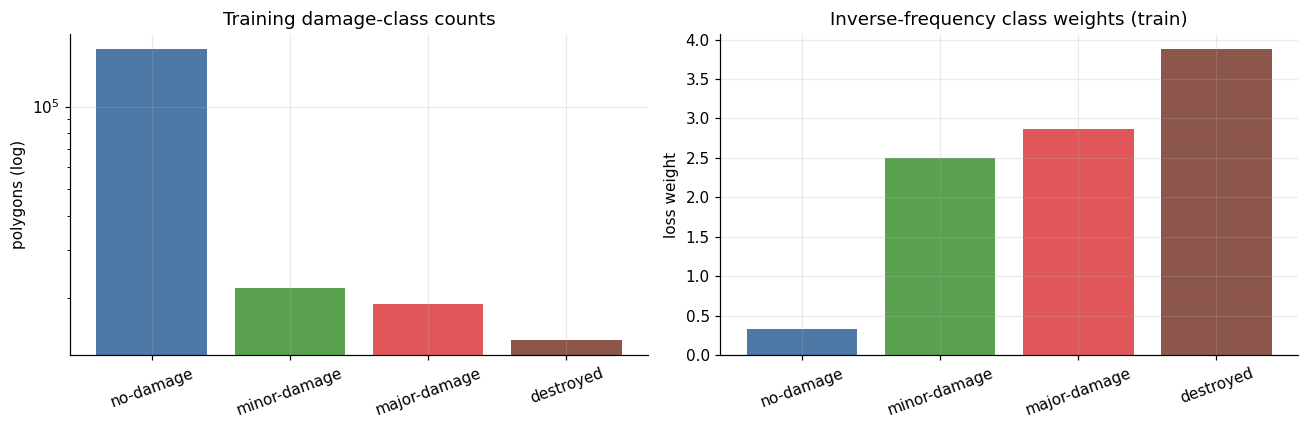

In [6]:
train_buildings = buildings[buildings.split == 'train']
train_labelled = train_buildings[train_buildings.label.notna()].copy()

class_counts = train_labelled['subtype'].value_counts().reindex(DAMAGE_CLASSES).fillna(0).astype(int)
class_share = (100 * class_counts / class_counts.sum()).round(2)
inverse_frequency = class_counts.sum() / (len(DAMAGE_CLASSES) * class_counts.clip(lower=1))
balance = pd.DataFrame({'train_polygons': class_counts, 'share_percent': class_share,
                        'inverse_freq_weight': inverse_frequency.round(3)})
print('Training damage-class balance (labelled polygons only):')
display(balance)
print(f'imbalance ratio (majority / minority): {class_counts.max() / max(class_counts.min(), 1):.1f}x')
balance.to_csv(OUTPUT_DIR / 'damage_class_balance_train.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(DAMAGE_CLASSES, class_counts, color=CLASS_COLORS[:4])
axes[0].set(yscale='log', ylabel='polygons (log)', title='Training damage-class counts')
axes[1].bar(DAMAGE_CLASSES, inverse_frequency, color=CLASS_COLORS[:4])
axes[1].set(ylabel='loss weight', title='Inverse-frequency class weights (train)')
for axis in axes:
    axis.tick_params(axis='x', labelrotation=20)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'training_class_balance.png', dpi=150)
plt.show()

### 4.2 Damage composition by training event

The class mix differs sharply from one event to the next, so scene sampling is stratified by event and no single disaster is allowed to disappear.

Training damage composition by event (% of labelled polygons):


subtype,no-damage,minor-damage,major-damage,destroyed
disaster,,,,
mexico-earthquake,99.6,0.4,0.0,0.0
sunda-tsunami,97.8,0.0,0.8,1.4
midwest-flooding,95.9,1.6,1.5,1.0
guatemala-volcano,92.3,1.6,1.6,4.5
moore-tornado,86.1,4.1,2.1,7.7
palu-tsunami,81.3,0.0,1.9,16.8
lower-puna-volcano,79.5,2.0,1.0,17.5
tuscaloosa-tornado,76.1,13.5,3.2,7.2
hurricane-florence,74.2,2.2,22.5,1.0


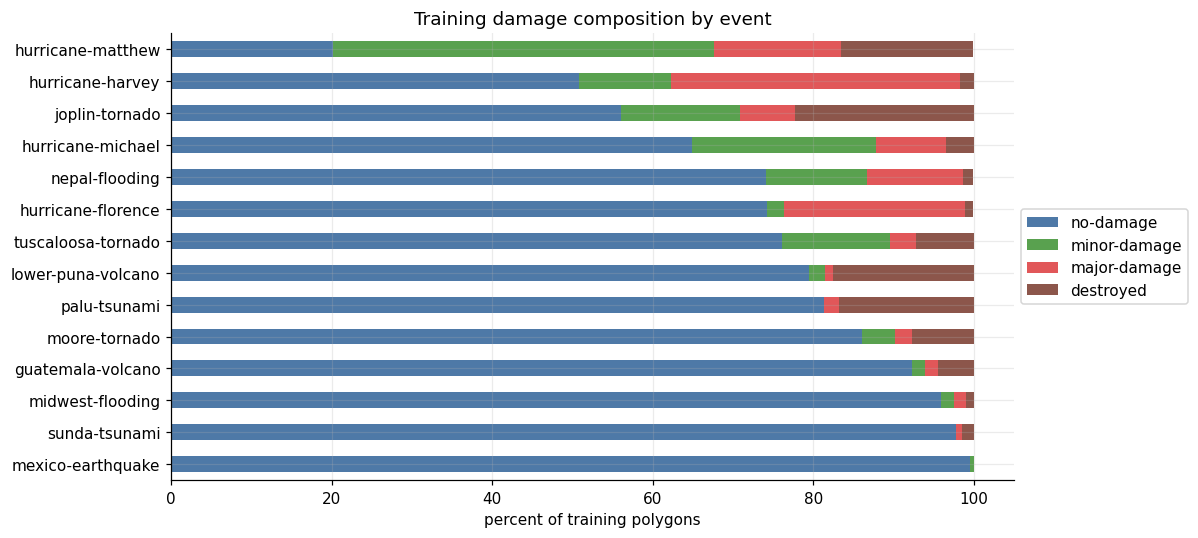

In [7]:
train_event = pd.crosstab(train_labelled['disaster'], train_labelled['subtype']).reindex(
    columns=DAMAGE_CLASSES, fill_value=0)
train_event_pct = train_event.div(train_event.sum(axis=1), axis=0).mul(100).round(1)
train_event_pct = train_event_pct.loc[train_event_pct[DAMAGE_CLASSES[1:]].sum(axis=1).sort_values().index]
print('Training damage composition by event (% of labelled polygons):')
display(train_event_pct)

fig, ax = plt.subplots(figsize=(11, 5))
train_event_pct.plot.barh(stacked=True, ax=ax, color=CLASS_COLORS[:4])
ax.set(xlabel='percent of training polygons', ylabel='', title='Training damage composition by event')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'training_composition_by_event.png', dpi=150)
plt.show()
train_event_pct.to_csv(OUTPUT_DIR / 'training_composition_by_event.csv')

### 4.3 Buildings per training scene

Empty and near-empty scenes are common and vary by origin. Sampling scenes uniformly would spend most of the budget decoding tiles with nothing to crop, so extraction later requires a minimum building count per scene.

training scenes: 3,135  |  median buildings/scene: 29  |  empty scenes: 9.8%


,scenes,empty_scenes,median,total
origin,,,,
tier1,1555,86,29.0,122866
tier3,1580,220,28.0,102640


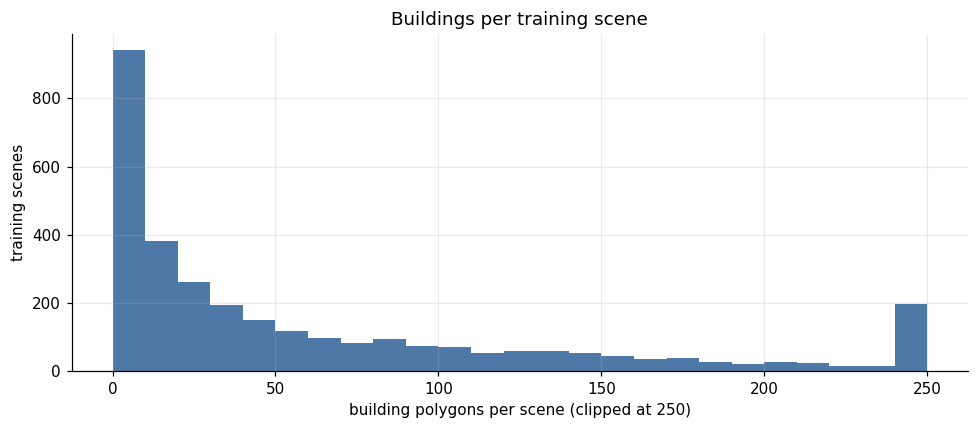

In [8]:
train_scene_meta = scene_meta[scene_meta.split == 'train']
per_scene = train_scene_meta['n_buildings']
print(f'training scenes: {len(train_scene_meta):,}  |  median buildings/scene: {per_scene.median():.0f}'
      f'  |  empty scenes: {(per_scene == 0).mean() * 100:.1f}%')
display(train_scene_meta.groupby('origin')['n_buildings'].agg(
    scenes='size', empty_scenes=lambda s: int((s == 0).sum()), median='median', total='sum').round(1))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(per_scene.clip(upper=250), bins=np.arange(0, 260, 10), color=NONFIRE_COLOR)
ax.set(xlabel='building polygons per scene (clipped at 250)', ylabel='training scenes',
       title='Buildings per training scene')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'training_buildings_per_scene.png', dpi=150)
plt.show()

### 4.4 Footprint geometry/setting `PATCH_SIZE`

Bounding boxes are measured in **pixels**. `PATCH_SIZE = 64` covers most footprints near native resolution; `BBOX_PAD = 10` px keeps visible context (debris, scorch, standing water) around each building. Footprints with a side under `MIN_BBOX_PX` become interpolation artefacts after padding and upscaling.

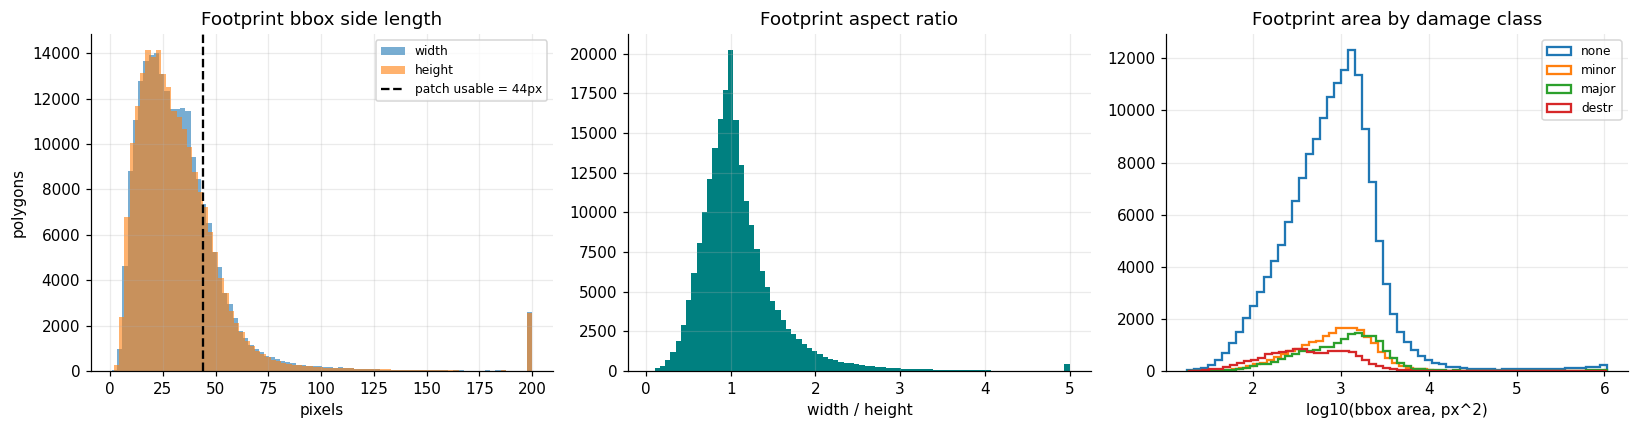

percentiles of max(bbox width, height), px:


,px
0.50,33.9
0.75,46.6
0.90,60.9
0.95,78.1
0.99,299.3


footprints with a side < 8px: 8,185 (3.77%)


In [9]:
geo = train_labelled[(train_labelled.bw > 0) & (train_labelled.bh > 0)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(np.clip(geo.bw, 0, 200), bins=80, alpha=.6, label='width')
axes[0].hist(np.clip(geo.bh, 0, 200), bins=80, alpha=.6, label='height')
axes[0].axvline(PATCH_SIZE - 2 * BBOX_PAD, color='k', ls='--',
                label=f'patch usable = {PATCH_SIZE - 2 * BBOX_PAD}px')
axes[0].set(xlabel='pixels', ylabel='polygons', title='Footprint bbox side length')
axes[0].legend(fontsize=8)
axes[1].hist(np.clip(geo.aspect, 0, 5), bins=80, color='teal')
axes[1].set(xlabel='width / height', title='Footprint aspect ratio')
for index, name in enumerate(DAMAGE_CLASSES):
    values = geo.loc[geo.label == index, 'barea']
    axes[2].hist(np.log10(values.clip(lower=1)), bins=60, histtype='step', lw=1.5, label=SHORT[index])
axes[2].set(xlabel='log10(bbox area, px^2)', title='Footprint area by damage class')
axes[2].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'training_footprint_geometry.png', dpi=150)
plt.show()

longest_side = geo[['bw', 'bh']].max(axis=1)
print('percentiles of max(bbox width, height), px:')
display(longest_side.quantile([.5, .75, .9, .95, .99]).round(1).rename('px').to_frame())
tiny = (geo.bw < MIN_BBOX_PX) | (geo.bh < MIN_BBOX_PX)
print(f'footprints with a side < {MIN_BBOX_PX}px: {int(tiny.sum()):,} ({100 * tiny.mean():.2f}%)')

### 4.5 Representative footprints by damage class

One row per class, each cell showing the **pre | post** crop of a training footprint. This is the eyeball check that severity increases down the rows and that pre/post are co-registered. Augmentation is chosen to leave that change signal intact.

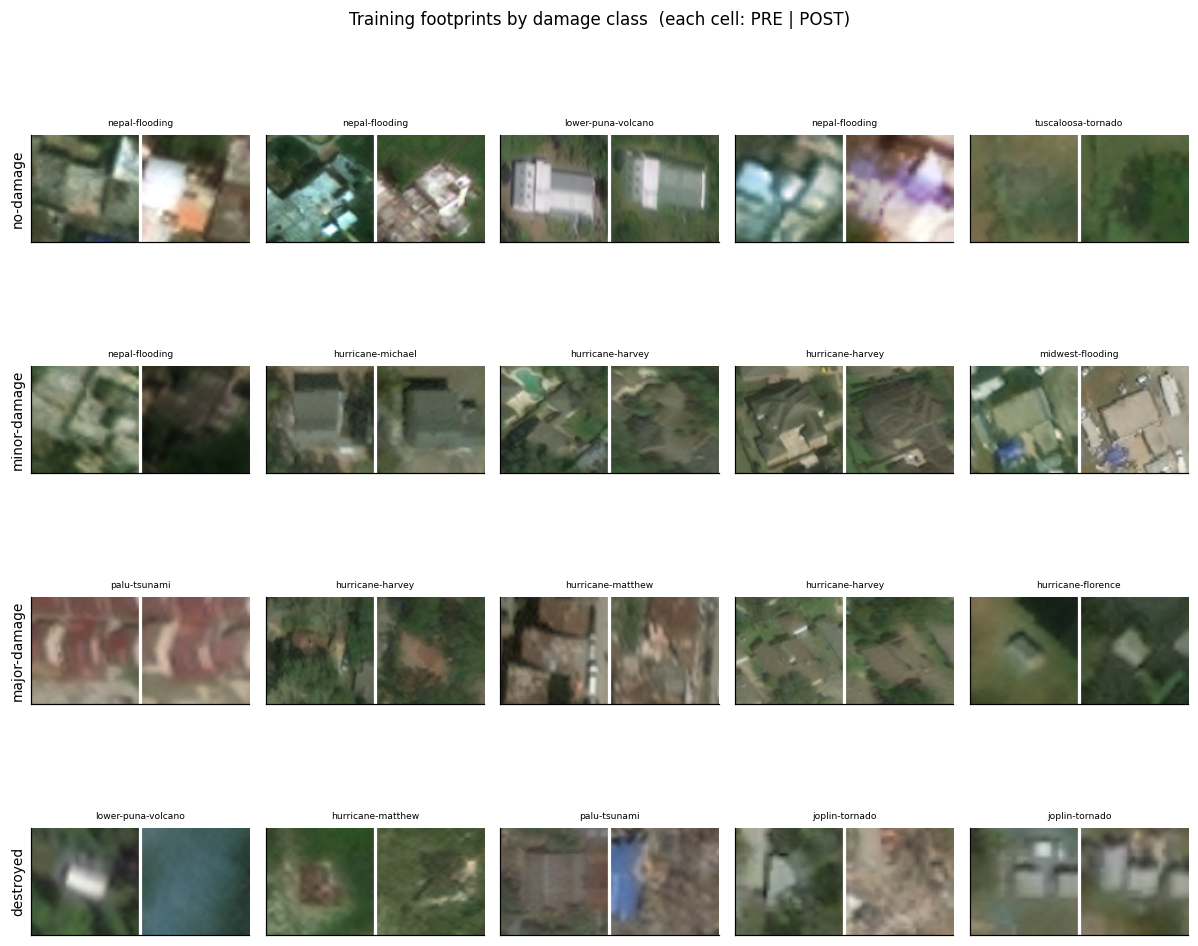

decoded 40 tiles for this figure


In [10]:
images = splits_df[(splits_df.subdir == 'images') & splits_df.exists]
image_paths = (images.pivot(index='scene_id', columns='kind', values='resolved_path')
               .rename(columns={'pre_disaster': 'img_pre', 'post_disaster': 'img_post'}))
gallery = train_labelled.merge(image_paths[['img_pre', 'img_post']], left_on='scene_id', right_index=True)

fig, axes = plt.subplots(len(DAMAGE_CLASSES), EXAMPLES_PER_CLASS,
                         figsize=(2.2 * EXAMPLES_PER_CLASS, 2.4 * len(DAMAGE_CLASSES)), squeeze=False)
tile_cache = {}


def read_tile(path):
    if path not in tile_cache:
        with Image.open(path) as handle:
            tile_cache[path] = np.asarray(handle.convert('RGB'), np.uint8)
    return tile_cache[path]


for row_index, name in enumerate(DAMAGE_CLASSES):
    pool = gallery[gallery.subtype == name]
    picks = pool.sample(min(EXAMPLES_PER_CLASS, len(pool)), random_state=RANDOM_SEED)
    for col_index in range(EXAMPLES_PER_CLASS):
        axis = axes[row_index, col_index]
        axis.set_xticks([]); axis.set_yticks([]); axis.grid(False)
        if col_index >= len(picks):
            axis.axis('off')
            continue
        record = picks.iloc[col_index]
        crops = []
        for path in (record.img_pre, record.img_post):
            full = read_tile(path)
            left = max(0, int(record.minx) - BBOX_PAD)
            top = max(0, int(record.miny) - BBOX_PAD)
            right = min(full.shape[1], int(record.maxx) + BBOX_PAD)
            bottom = min(full.shape[0], int(record.maxy) + BBOX_PAD)
            patch = full[top:bottom, left:right]
            if patch.size == 0:
                patch = np.zeros((8, 8, 3), np.uint8)
            crops.append(np.asarray(Image.fromarray(patch).resize((96, 96), Image.BILINEAR)))
        axis.imshow(np.concatenate([crops[0], np.full((96, 3, 3), 255, np.uint8), crops[1]], axis=1))
        axis.set_title(record.disaster, fontsize=6)
    axes[row_index, 0].set_ylabel(name, fontsize=9)
fig.suptitle('Training footprints by damage class  (each cell: PRE | POST)', fontsize=11)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'training_examples_by_class.png', dpi=150)
plt.show()
print('decoded', len(tile_cache), 'tiles for this figure')

## 5 · Cleaning

Sections 5.1–5.4 measure the cost of each candidate rule before anything is dropped. Section 5.5 turns the ones that have a real fix into an actual filter and produces `clean_buildings`, the table Section 7 extracts patches from.

In [11]:
tiny_footprint = (buildings.bw < MIN_BBOX_PX) | (buildings.bh < MIN_BBOX_PX)
cleaning_summary = pd.DataFrame([
    {'check': 'indexed files missing on disk', 'count': int((~splits_df.exists).sum()),
     'action': 'report only — none found; would block the affected scene in §5.5 if any appeared'},
    {'check': 'scenes not complete on disk', 'count': int((~scene_summary.complete_on_disk).sum()),
     'action': 'excluded from patch extraction (§5.5, incomplete-scene rule)'},
    {'check': 'scenes assigned to multiple splits', 'count': int((~scene_summary.one_split_only).sum()),
     'action': 'report only — a split-index bug to fix upstream, not a per-row cleaning decision'},
    {'check': 'scenes missing an image/label role', 'count': int((~scene_summary.image_label_roles_present).sum()),
     'action': 'excluded from patch extraction (§5.5, incomplete-scene rule)'},
    {'check': 'unreadable label files', 'count': int(scene_meta.label_error.notna().sum()),
     'action': 'contributes zero polygons already (§3), so implicitly excluded from patch extraction'},
    {'check': 'un-classified annotations', 'count': int((buildings.subtype == 'un-classified').sum()),
     'action': 'excluded from clean_buildings (§5.5)'},
    {'check': 'missing damage subtype', 'count': int((buildings.subtype == 'missing').sum()),
     'action': 'excluded from clean_buildings (§5.5)'},
    {'check': 'invalid / unparseable geometries', 'count': int(scene_meta.n_invalid_geometry.sum()),
     'action': 'never added to buildings at scan time (§3) — nothing further to exclude'},
    {'check': f'footprints with a side < {MIN_BBOX_PX}px', 'count': int(tiny_footprint.sum()),
     'action': 'excluded from clean_buildings (§5.5)'},
])
display(cleaning_summary)
cleaning_summary.to_csv(OUTPUT_DIR / 'cleaning_summary.csv', index=False)

print('\nexclusion-rule rates by split (should be roughly uniform, or the rule biases the comparison):')
rule_rates = pd.DataFrame({
    'unclassified_%': 100 * buildings.subtype.eq('un-classified').groupby(buildings.split).mean(),
    'tiny_footprint_%': 100 * tiny_footprint.groupby(buildings.split).mean(),
    'invalid_geometry': scene_meta.groupby('split').n_invalid_geometry.sum(),
}).reindex(SPLIT_ORDER).round(3)
display(rule_rates)
rule_rates.to_csv(OUTPUT_DIR / 'exclusion_rule_rates_by_split.csv')

,check,count,action
0,indexed files missing on disk,0,report only — none found; would block the affe...
1,scenes not complete on disk,0,"excluded from patch extraction (§5.5, incomple..."
2,scenes assigned to multiple splits,0,report only — a split-index bug to fix upstrea...
3,scenes missing an image/label role,0,"excluded from patch extraction (§5.5, incomple..."
4,unreadable label files,0,"contributes zero polygons already (§3), so imp..."
5,un-classified annotations,14011,excluded from clean_buildings (§5.5)
6,missing damage subtype,0,excluded from clean_buildings (§5.5)
7,invalid / unparseable geometries,0,never added to buildings at scan time (§3) — n...
8,footprints with a side < 8px,16345,excluded from clean_buildings (§5.5)



exclusion-rule rates by split (should be roughly uniform, or the rule biases the comparison):


,unclassified_%,tiny_footprint_%,invalid_geometry
split,,,
train,3.675,4.108,0
val,4.079,3.553,0
test_id,2.087,3.137,0
test_ood,3.302,4.023,0


### 5.1 Un-classified annotations

`un-classified` is the annotators' "could not assess" value, not a damage level, so it is excluded from four-class modelling. The per-event rate is the closest thing xBD has to an occlusion signal.

Un-classified annotation rate by split:


,unclassified,annotations,percent
split,,,
train,8287,225506,3.67
val,1256,30794,4.08
test_id,1915,91755,2.09
test_ood,2553,77313,3.30


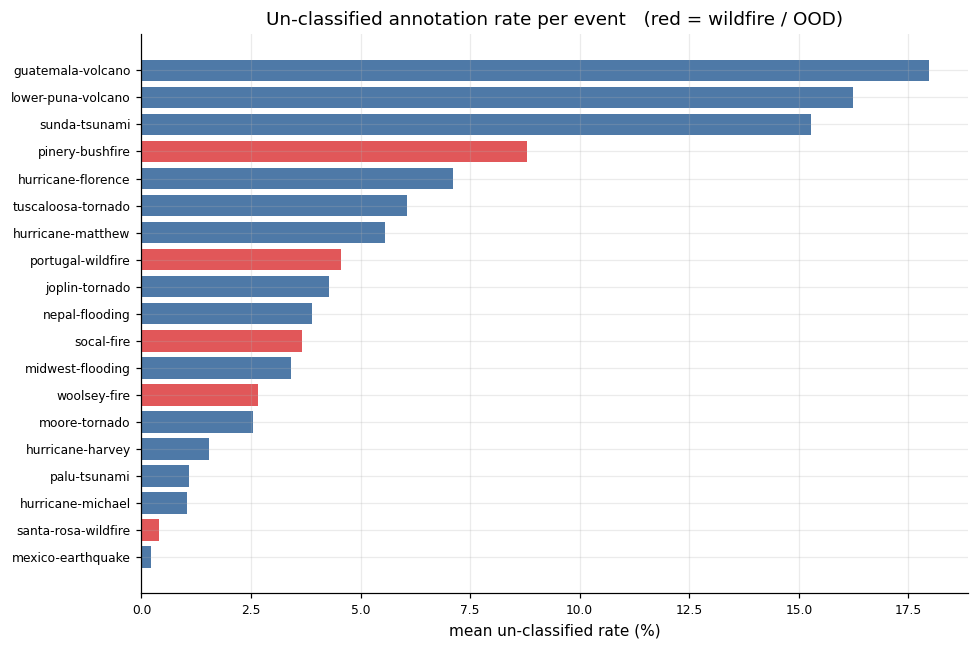

In [12]:
unclassified = (buildings.assign(is_unc=buildings.subtype.eq('un-classified'))
                .groupby('split')['is_unc'].agg(unclassified='sum', annotations='size'))
unclassified['percent'] = (100 * unclassified.unclassified / unclassified.annotations).round(2)
print('Un-classified annotation rate by split:')
display(unclassified.reindex(SPLIT_ORDER))
unclassified.to_csv(OUTPUT_DIR / 'unclassified_rate_by_split.csv')

by_event = (buildings.assign(is_unc=buildings.subtype.eq('un-classified'))
            .groupby('disaster')['is_unc'].mean().mul(100).sort_values())
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(by_event.index, by_event.values,
        color=[FIRE_COLOR if event in FIRE_EVENTS else NONFIRE_COLOR for event in by_event.index])
ax.set(xlabel='mean un-classified rate (%)', ylabel='',
       title='Un-classified annotation rate per event   (red = wildfire / OOD)')
ax.tick_params(labelsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'unclassified_rate_by_event.png', dpi=150)
plt.show()

### 5.2 Image quality on a sampled set

Fully decode a set of post-disaster tiles and measure brightness, contrast, blank fractions, and an edge-density proxy. The set is a random stratified sample **plus the 300 scenes with the highest un-classified rate**, so 5.3 has range on the occlusion proxy. Extreme values are flagged for manual review, not removed. This also confirms the tiles are a uniform format.

QC scenes: 788  (500 random + 300 highest un-classified)


post-disaster scenes decoded: 788  |  flagged for review: 1
resolution x mode: {('1024x1024', 'RGB'): 788}


brightness        contrast        edge_density       
               mean    std     mean    std         mean    std
split                                                         
test_id       0.296  0.079    0.108  0.046        7.999  3.080
test_ood      0.315  0.083    0.102  0.035        9.110  3.272
train         0.329  0.127    0.113  0.055        7.537  2.819
val           0.365  0.129    0.113  0.057        7.144  2.323

,scene_id,disaster,split,size,mode,brightness,contrast,dark_fraction,bright_fraction,edge_density,flag
658,nepal-flooding_00000502,nepal-flooding,train,1024x1024,RGB,0.44366,0.01617,0.0,0.0,4.874811,True


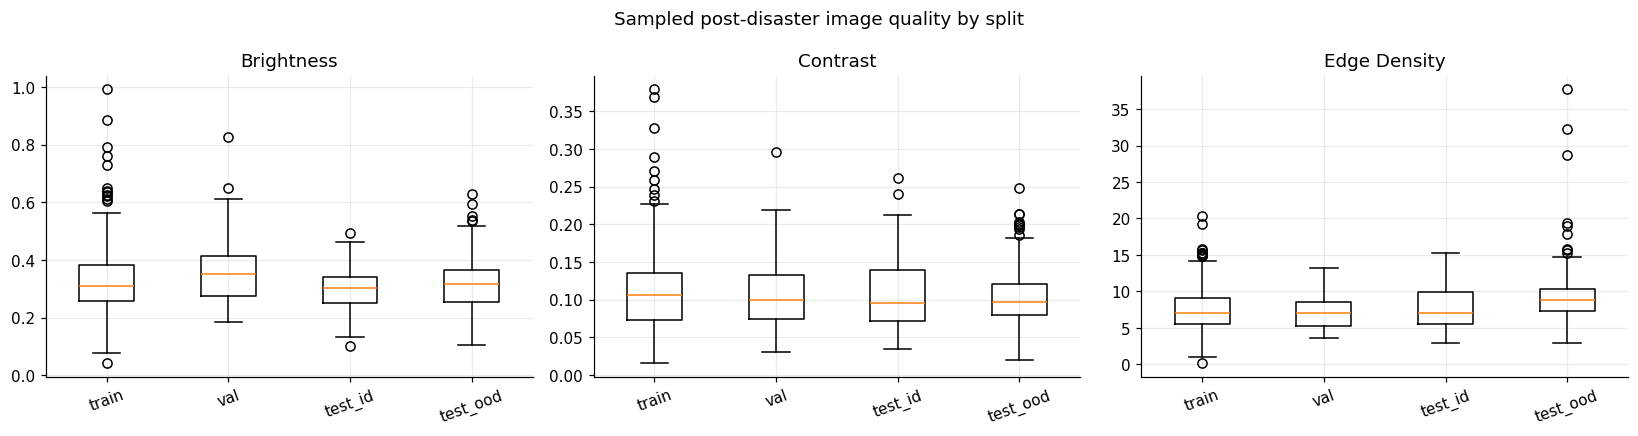

In [13]:
post_images = images[images.kind == 'post_disaster'].drop_duplicates('scene_id')

unclassified_fraction = (buildings.assign(is_unc=buildings.subtype.eq('un-classified'))
                         .groupby('scene_id')['is_unc'].agg(n_buildings='size', n_unc='sum'))
unclassified_fraction['unc_frac'] = unclassified_fraction.n_unc / unclassified_fraction.n_buildings.clip(lower=1)
high_unclassified = unclassified_fraction[unclassified_fraction.n_buildings >= 10].nlargest(300, 'unc_frac').index

qc_ids = pd.Index(post_images.sample(min(QC_SAMPLE_SCENES, len(post_images)), random_state=RANDOM_SEED).scene_id)
qc_ids = qc_ids.union(pd.Index(high_unclassified))
qc_scenes = post_images[post_images.scene_id.isin(qc_ids)]
print(f'QC scenes: {len(qc_scenes):,}  ({QC_SAMPLE_SCENES} random + {len(high_unclassified)} highest un-classified)')

quality_rows = []
for record in qc_scenes.itertuples(index=False):
    with Image.open(record.resolved_path) as handle:
        size, mode = handle.size, handle.mode
        gray = np.asarray(handle.convert('RGB'), np.float32).mean(axis=2)
    quality_rows.append({
        'scene_id': record.scene_id, 'disaster': record.disaster, 'split': record.split,
        'size': f'{size[0]}x{size[1]}', 'mode': mode,
        'brightness': gray.mean() / 255, 'contrast': gray.std() / 255,
        'dark_fraction': float((gray < 6).mean()), 'bright_fraction': float((gray > 250).mean()),
        'edge_density': float(np.abs(np.diff(gray, axis=0)).mean() + np.abs(np.diff(gray, axis=1)).mean()),
    })
quality_df = pd.DataFrame(quality_rows)
quality_df['flag'] = ((quality_df.dark_fraction > 0.98) | (quality_df.bright_fraction > 0.98)
                      | (quality_df.contrast < 0.02))
print(f'post-disaster scenes decoded: {len(quality_df):,}  |  flagged for review: {int(quality_df.flag.sum())}')
print('resolution x mode:', quality_df.groupby(["size", "mode"]).size().to_dict())
display(quality_df.groupby('split')[['brightness', 'contrast', 'edge_density']].agg(['mean', 'std']).round(3))
if quality_df.flag.any():
    display(quality_df[quality_df.flag].head(10))
quality_df.to_csv(OUTPUT_DIR / 'image_quality_sample.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, column in zip(axes, ['brightness', 'contrast', 'edge_density']):
    axis.boxplot([quality_df.loc[quality_df.split == split, column].to_numpy() for split in SPLIT_ORDER])
    axis.set_xticks(range(1, len(SPLIT_ORDER) + 1))
    axis.set_xticklabels(SPLIT_ORDER, rotation=20)
    axis.set_title(column.replace('_', ' ').title())
fig.suptitle('Sampled post-disaster image quality by split')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'image_quality_by_split.png', dpi=150)
plt.show()

### 5.3 Occlusion: do the pixels agree with the annotators?

xBD has no cloud or smoke label. If `un-classified` really tracked occlusion, high-rate scenes would also look texture-poor and washed out. This correlates the per-scene un-classified rate against the image statistics from 5.2, over the enriched sample. A weak or absent correlation is itself the finding: neither signal is trustworthy alone, so nothing is removed on it.

scenes with >= 10 buildings in the sample: 494

Spearman rho vs. un-classified rate:


,spearman_rho
brightness,0.050
contrast,-0.078
edge_density,-0.183


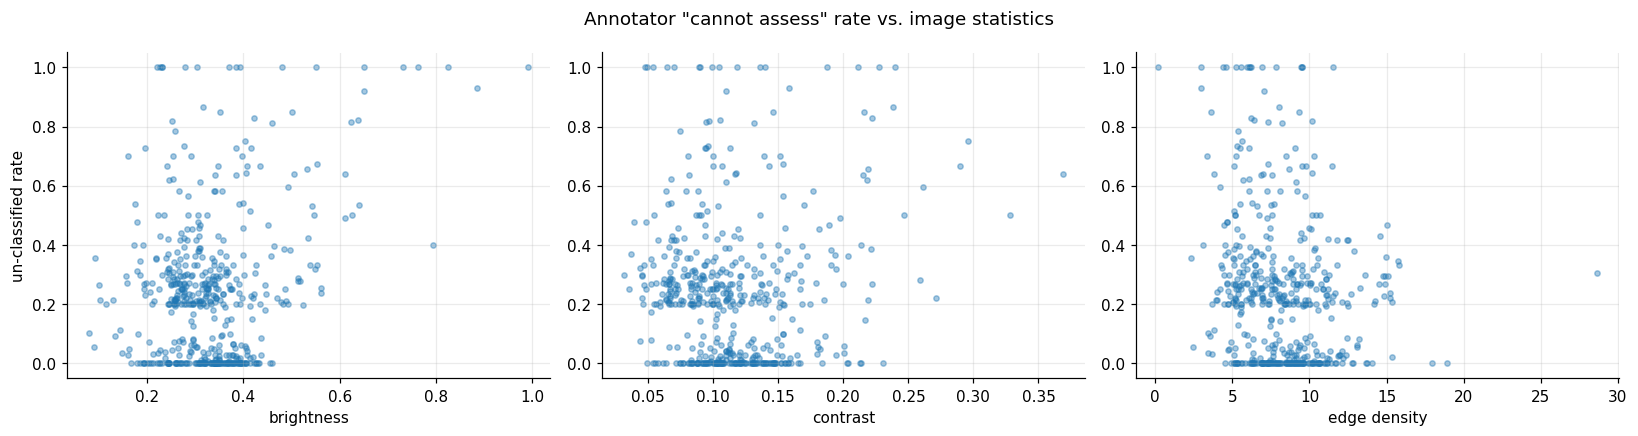

In [14]:
occlusion = quality_df.merge(unclassified_fraction, on='scene_id', how='left')
occlusion = occlusion[occlusion.n_buildings >= 10].dropna(subset=['unc_frac'])
print(f'scenes with >= 10 buildings in the sample: {len(occlusion)}')

correlation = (occlusion[['unc_frac', 'brightness', 'contrast', 'edge_density']]
               .corr(method='spearman')['unc_frac'].drop('unc_frac'))
print('\nSpearman rho vs. un-classified rate:')
display(correlation.round(3).rename('spearman_rho').to_frame())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, column in zip(axes, ['brightness', 'contrast', 'edge_density']):
    axis.scatter(occlusion[column], occlusion.unc_frac, s=12, alpha=.4)
    axis.set(xlabel=column.replace('_', ' '),
             ylabel='un-classified rate' if column == 'brightness' else '')
fig.suptitle('Annotator "cannot assess" rate vs. image statistics')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'occlusion_proxy_correlation.png', dpi=150)
plt.show()

### 5.4 Near-duplicate spot check

A perceptual difference hash over the QC sample flags suspiciously similar post-disaster tiles. Cross-split matches would be the ones that could leak; xBD tiles a disaster area into non-overlapping chips and the split is scene-level, so none are expected.

In [15]:
def dhash_bits(path, hash_size=8):
    with Image.open(path) as handle:
        pixels = np.asarray(handle.convert('L').resize((hash_size + 1, hash_size), Image.BILINEAR),
                            dtype=np.int16)
    return ''.join('1' if bit else '0' for bit in (pixels[:, 1:] > pixels[:, :-1]).ravel())


hash_df = qc_scenes[['scene_id', 'disaster', 'split', 'resolved_path']].copy()
hash_df['hash'] = hash_df['resolved_path'].map(dhash_bits)
bits = np.array([[char == '1' for char in value] for value in hash_df['hash']], dtype=bool)
hamming = (bits[:, None, :] != bits[None, :, :]).sum(axis=-1)
np.fill_diagonal(hamming, 64)

NEAR_DUP_BITS = 6
left, right = np.where(np.triu(hamming <= NEAR_DUP_BITS, k=1))
near_duplicates = pd.DataFrame({
    'scene_a': hash_df.scene_id.to_numpy()[left], 'scene_b': hash_df.scene_id.to_numpy()[right],
    'split_a': hash_df.split.to_numpy()[left], 'split_b': hash_df.split.to_numpy()[right],
    'hamming': hamming[left, right],
})
cross_split = near_duplicates[near_duplicates.split_a != near_duplicates.split_b]
print(f'near-duplicate pairs in the {len(hash_df):,}-scene sample (<= {NEAR_DUP_BITS}/64 bits): {len(near_duplicates)}')
print(f'of which cross-split (the ones that would leak):                      {len(cross_split)}')
if len(cross_split):
    display(cross_split.head(20))
near_duplicates.to_csv(OUTPUT_DIR / 'near_duplicate_pairs_sample.csv', index=False)

near-duplicate pairs in the 788-scene sample (<= 6/64 bits): 27
of which cross-split (the ones that would leak):                      8


,scene_a,scene_b,split_a,split_b,hamming
1,socal-fire_00000251,joplin-tornado_00000013,test_ood,train,5
2,socal-fire_00000251,lower-puna-volcano_00000235,test_ood,train,6
3,socal-fire_00000251,moore-tornado_00000087,test_ood,train,5
4,socal-fire_00000251,nepal-flooding_00000059,test_ood,train,6
5,socal-fire_00000251,tuscaloosa-tornado_00000084,test_ood,train,6
6,socal-fire_00000319,joplin-tornado_00000013,test_ood,train,6
7,socal-fire_00000319,moore-tornado_00000087,test_ood,train,6
8,socal-fire_00000319,tuscaloosa-tornado_00000084,test_ood,train,5


### 5.5 Applying the exclusion rules

Sections 5.1–5.4 only measured cost. This applies the rules that have a real fix, in order: drop `un-classified`/`missing` polygons (no damage level to train against), then drop degenerate and tiny footprints among what remains (nothing sensible to crop), then drop any scene that is not complete on disk. Invalid geometries never entered `buildings` in the first place (§3); a scene assigned to multiple splits, or a genuinely unreadable label file, is a data-integrity bug to fix upstream rather than a per-row rule — both stay report-only, as flagged in the cleaning summary above. `clean_buildings` is the result, and it is what Section 7 extracts patches from. Everything above this cell, and all of Section 6, keeps using the unfiltered `buildings`/`scene_meta` on purpose — this is the one place in the notebook where rows actually get dropped.

In [16]:
step0 = buildings
unclassified_or_missing = step0['label'].isna()
step1 = step0.loc[~unclassified_or_missing]

degenerate_geometry = (step1.bw <= 0) | (step1.bh <= 0)
step2 = step1.loc[~degenerate_geometry]

tiny_footprint_step = (step2.bw < MIN_BBOX_PX) | (step2.bh < MIN_BBOX_PX)
step3 = step2.loc[~tiny_footprint_step]

usable_scene = (scene_summary.set_index('scene_id')[['complete_on_disk', 'image_label_roles_present']]
                .all(axis=1))
incomplete_scene = ~step3['scene_id'].map(usable_scene).fillna(False)
clean_buildings = step3.loc[~incomplete_scene].copy()

exclusion_ledger = pd.DataFrame([
    {'rule': 'un-classified / missing subtype', 'unit': 'building polygons', 'scope': len(step0),
     'removed': int(unclassified_or_missing.sum()), 'kept': len(step1),
     'action': 'excluded from clean_buildings',
     'why': 'not a damage level — the annotator could not assess the building, or the JSON carried no subtype at all'},
    {'rule': 'degenerate geometry', 'unit': 'building polygons', 'scope': len(step1),
     'removed': int(degenerate_geometry.sum()), 'kept': len(step2),
     'action': 'excluded from clean_buildings',
     'why': 'zero/negative-area bbox cannot be cropped'},
    {'rule': f'tiny footprint (< {MIN_BBOX_PX}px side)', 'unit': 'building polygons', 'scope': len(step2),
     'removed': int(tiny_footprint_step.sum()), 'kept': len(step3),
     'action': 'excluded from clean_buildings',
     'why': f'a side under {MIN_BBOX_PX}px becomes an interpolation artefact once padded and resized to {PATCH_SIZE}px'},
    {'rule': 'incomplete scene', 'unit': 'building polygons', 'scope': len(step3),
     'removed': int(incomplete_scene.sum()), 'kept': len(clean_buildings),
     'action': 'excluded from clean_buildings',
     'why': 'a usable sample needs pre image + post image + post label all present on disk'},
])
display(exclusion_ledger[['rule', 'unit', 'scope', 'removed', 'kept', 'action', 'why']])
exclusion_ledger.to_csv(OUTPUT_DIR / 'exclusion_ledger.csv', index=False)

print(f'\nbuildings before cleaning : {len(buildings):,}')
print(f'buildings after cleaning  : {len(clean_buildings):,}  ({100 * len(clean_buildings) / len(buildings):.2f}% kept)')
print('\ndamage-class counts per split, after cleaning:')
display(pd.crosstab(clean_buildings['split'], clean_buildings['subtype'])
        .reindex(index=SPLIT_ORDER, columns=DAMAGE_CLASSES, fill_value=0))

clean_buildings.to_parquet(CACHE_DIR / 'clean_buildings.parquet', index=False)

,rule,unit,scope,removed,kept,action,why
0,un-classified / missing subtype,building polygons,425368,14011,411357,excluded from clean_buildings,not a damage level — the annotator could not a...
1,degenerate geometry,building polygons,411357,0,411357,excluded from clean_buildings,zero/negative-area bbox cannot be cropped
2,tiny footprint (< 8px side),building polygons,411357,14458,396899,excluded from clean_buildings,a side under 8px becomes an interpolation arte...
3,incomplete scene,building polygons,396899,0,396899,excluded from clean_buildings,a usable sample needs pre image + post image +...



buildings before cleaning : 425,368
buildings after cleaning  : 396,899  (93.31% kept)

damage-class counts per split, after cleaning:


subtype,no-damage,minor-damage,major-damage,destroyed
split,,,,
train,156261,21335,18637,12801
val,22059,3257,1800,1447
test_id,63669,10832,8235,4415
test_ood,59899,646,704,10902


## 6 · Split composition and domain-shift audit

These cross-split views **characterise** the inherited split and the wildfire OOD domain the model is graded on. They are context and audit — no cleaning threshold or training choice is tuned on them.

### 6.1 Damage-class composition per split

`test_ood` is larger than the whole training pool, so any dataset-wide statistic is dominated by wildfire — which is why every distribution above is reported per split.

Damage-class counts per split:


subtype,no-damage,minor-damage,major-damage,destroyed,un-classified,total
split,,,,,,
train,162462,21764,18976,14017,8287,225506
val,22798,3352,1838,1550,1256,30794
test_id,65781,11040,8364,4655,1915,91755
test_ood,61992,704,726,11338,2553,77313


Damage-class composition per split (%):


subtype,no-damage,minor-damage,major-damage,destroyed,un-classified
split,,,,,
train,72.04,9.65,8.41,6.22,3.67
val,74.03,10.89,5.97,5.03,4.08
test_id,71.69,12.03,9.12,5.07,2.09
test_ood,80.18,0.91,0.94,14.67,3.30


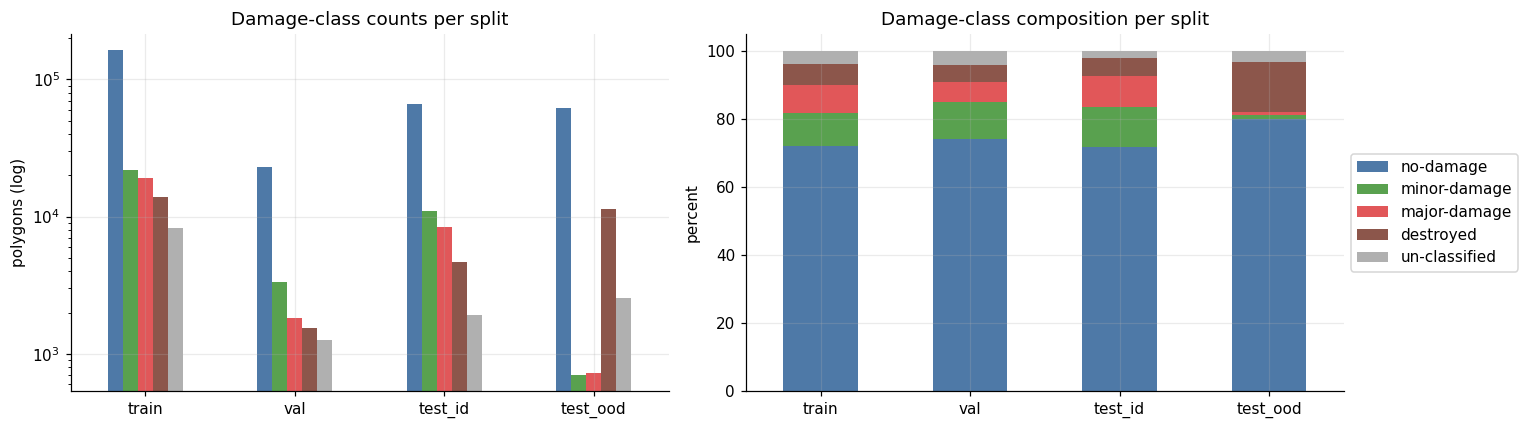

In [17]:
split_class = pd.crosstab(buildings['split'], buildings['subtype']).reindex(
    index=SPLIT_ORDER, columns=DAMAGE_ORDER, fill_value=0)
split_class = split_class.loc[:, split_class.sum() > 0]
split_pct = split_class.div(split_class.sum(axis=1), axis=0).mul(100).round(2)
print('Damage-class counts per split:')
display(split_class.assign(total=split_class.sum(axis=1)))
print('Damage-class composition per split (%):')
display(split_pct)
split_class.to_csv(OUTPUT_DIR / 'damage_class_counts_per_split.csv')
split_pct.to_csv(OUTPUT_DIR / 'damage_class_composition_per_split.csv')

colors = CLASS_COLORS[:split_class.shape[1]]
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
split_class.plot.bar(ax=axes[0], logy=True, color=colors, legend=False)
axes[0].set(ylabel='polygons (log)', xlabel='', title='Damage-class counts per split')
split_pct.plot.bar(stacked=True, ax=axes[1], color=colors)
axes[1].set(ylabel='percent', xlabel='', title='Damage-class composition per split')
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5))
for axis in axes:
    axis.tick_params(axis='x', labelrotation=0)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'damage_class_per_split.png', dpi=150)
plt.show()

### 6.2 Damage composition per event

Wildfire events (red) are qualitatively different from the training domain: intermediate damage nearly vanishes and `destroyed` more than doubles. A model that learns the training prior will be miscalibrated on fire even if its visual features transfer.

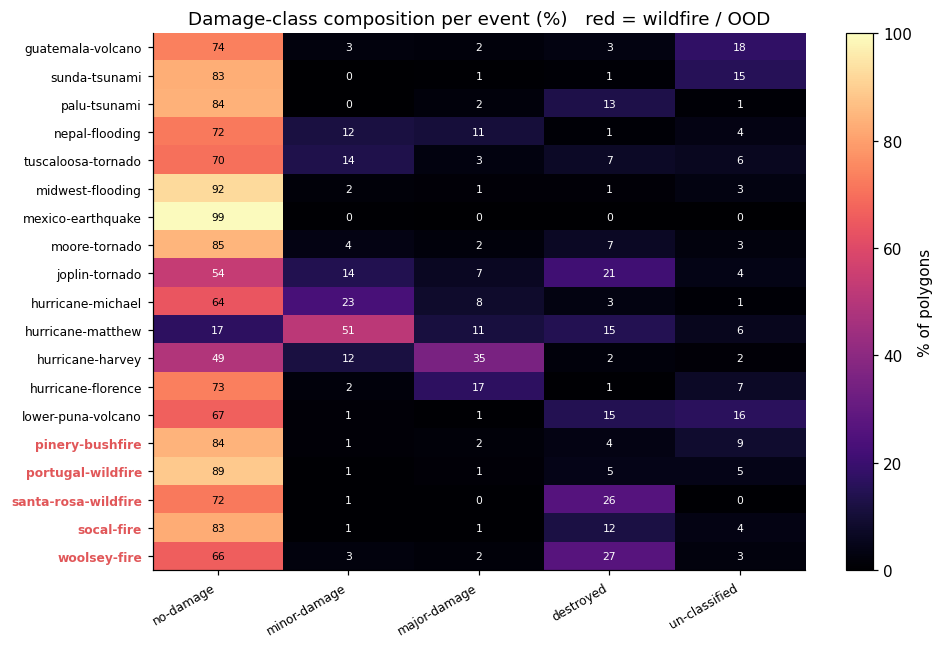

Mean class mix by domain:


,non-fire (train domain),wildfire (OOD domain)
subtype,,
no-damage,70.2,78.8
minor-damage,9.9,1.2
major-damage,7.2,1.1
destroyed,6.5,14.8


In [18]:
event_class = pd.crosstab(buildings['disaster'], buildings['subtype']).reindex(columns=DAMAGE_ORDER, fill_value=0)
event_class = event_class.loc[:, event_class.sum() > 0]
event_pct = event_class.div(event_class.sum(axis=1), axis=0).mul(100)
event_order = scenes.groupby('disaster').is_fire.first().sort_values().index
event_pct = event_pct.reindex(event_order)

fig, ax = plt.subplots(figsize=(9, 6))
image = ax.imshow(event_pct.values, cmap='magma', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(event_pct.shape[1]))
ax.set_xticklabels(event_pct.columns, rotation=30, ha='right', fontsize=8)
ax.set_yticks(range(len(event_pct)))
ax.set_yticklabels(event_pct.index, fontsize=8)
for row_index, event in enumerate(event_pct.index):
    if event in FIRE_EVENTS:
        ax.get_yticklabels()[row_index].set_color(FIRE_COLOR)
        ax.get_yticklabels()[row_index].set_fontweight('bold')
    for col_index in range(event_pct.shape[1]):
        value = event_pct.iloc[row_index, col_index]
        ax.text(col_index, row_index, f'{value:.0f}', ha='center', va='center', fontsize=7,
                color='white' if value < 55 else 'black')
ax.grid(False)
ax.set_title('Damage-class composition per event (%)   red = wildfire / OOD')
fig.colorbar(image, label='% of polygons')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'damage_composition_per_event_heatmap.png', dpi=150)
plt.show()

domain_mix = pd.DataFrame({
    'non-fire (train domain)': event_pct.loc[~event_pct.index.isin(FIRE_EVENTS), DAMAGE_CLASSES].mean().round(1),
    'wildfire (OOD domain)': event_pct.loc[event_pct.index.isin(FIRE_EVENTS), DAMAGE_CLASSES].mean().round(1),
})
print('Mean class mix by domain:')
display(domain_mix)
domain_mix.to_csv(OUTPUT_DIR / 'domain_class_mix.csv')

### 6.3 Empty scenes per event

The wildfire events top the empty-scene chart, they cover large stretches of forest and scrub. Uniform scene sampling would spend most of the OOD budget on tiles with no buildings, which is why extraction filters on a minimum building count, applied identically to every split.

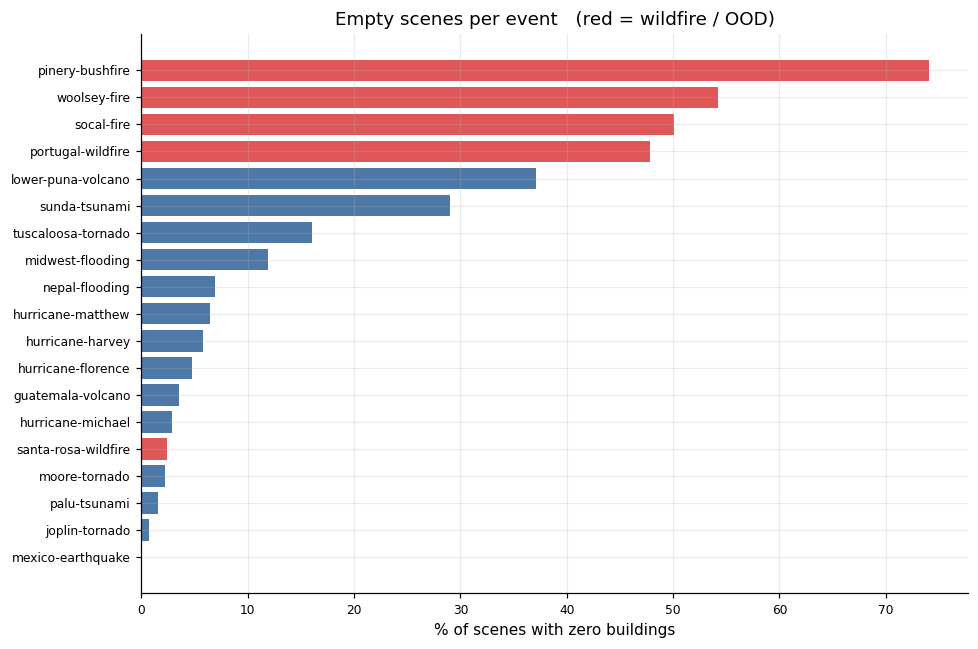

,scenes,empty_scenes,median_buildings,empty_percent
split,,,,
train,3135,306,29.0,9.8
val,392,43,31.5,11.0
test_id,1135,61,26.0,5.4
test_ood,6372,3448,0.0,54.1


In [19]:
empty_rate = (scene_meta.assign(empty=scene_meta.n_buildings.eq(0))
              .groupby('disaster').empty.mean().mul(100).sort_values())
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(empty_rate.index, empty_rate.values,
        color=[FIRE_COLOR if event in FIRE_EVENTS else NONFIRE_COLOR for event in empty_rate.index])
ax.set(xlabel='% of scenes with zero buildings', ylabel='',
       title='Empty scenes per event   (red = wildfire / OOD)')
ax.tick_params(labelsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'empty_scenes_per_event.png', dpi=150)
plt.show()

empty_by_split = scene_meta.groupby('split').agg(
    scenes=('scene_id', 'size'),
    empty_scenes=('n_buildings', lambda s: int((s == 0).sum())),
    median_buildings=('n_buildings', 'median'),
).reindex(SPLIT_ORDER)
empty_by_split['empty_percent'] = (100 * empty_by_split.empty_scenes / empty_by_split.scenes).round(1)
display(empty_by_split)
empty_by_split.to_csv(OUTPUT_DIR / 'empty_scenes_by_split.csv')

### 6.4 Acquisition geometry

Part of any transfer gap could be acquisition geometry rather than fire damage looking different. Overlaid distributions of GSD, off-nadir angle, and sun elevation show how far the wildfire captures sit from the training domain. (With only ~19 events, geometry is confounded with event identity.This is a limitation to state, not a variable to control for.)

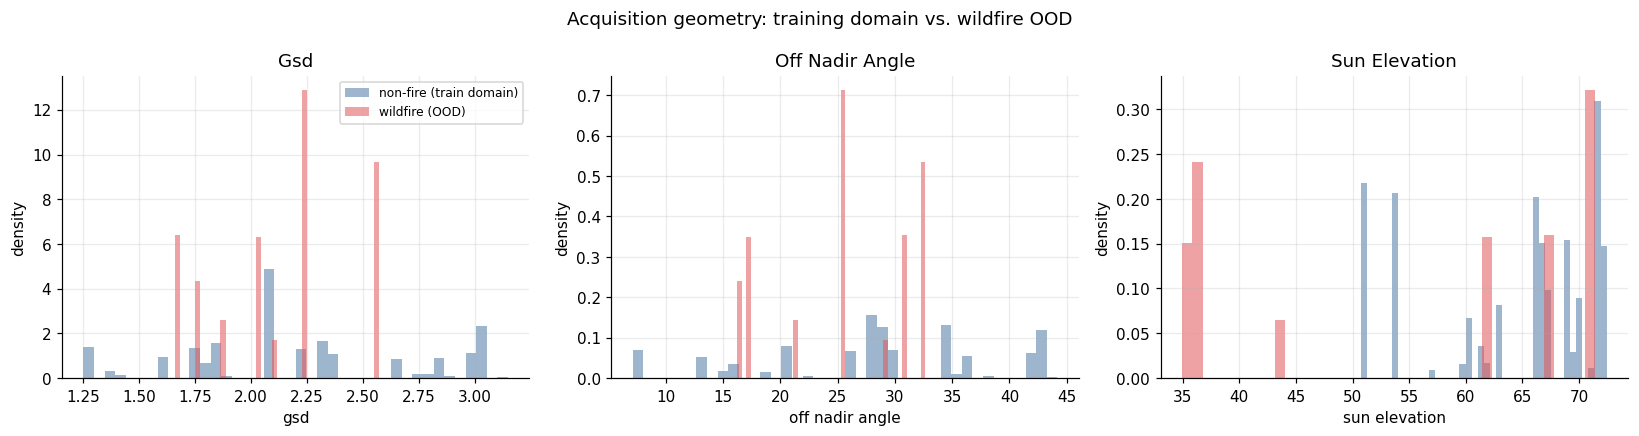

gsd       off_nadir_angle       sun_elevation       
                mean   std            mean   std          mean    std
domain                                                               
non-fire        2.21  0.52           28.53  9.87         64.44   7.45
wildfire (OOD)  2.12  0.31           25.60  5.98         55.03  15.92

In [20]:
meta_columns = ['gsd', 'off_nadir_angle', 'sun_elevation']
geo_meta = scene_meta.copy()
for column in meta_columns:
    geo_meta[column] = pd.to_numeric(geo_meta[column], errors='coerce')
geo_meta = geo_meta.dropna(subset=meta_columns)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, column in zip(axes, meta_columns):
    for mask, label, color in [(~geo_meta.is_fire, 'non-fire (train domain)', NONFIRE_COLOR),
                               (geo_meta.is_fire, 'wildfire (OOD)', FIRE_COLOR)]:
        axis.hist(geo_meta.loc[mask, column], bins=40, density=True, alpha=.55, label=label, color=color)
    axis.set(xlabel=column.replace('_', ' '), ylabel='density', title=column.replace('_', ' ').title())
axes[0].legend(fontsize=8)
fig.suptitle('Acquisition geometry: training domain vs. wildfire OOD')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'capture_geometry_domain_shift.png', dpi=150)
plt.show()

geometry_by_domain = (geo_meta.assign(domain=np.where(geo_meta.is_fire, 'wildfire (OOD)', 'non-fire'))
                      .groupby('domain')[meta_columns].agg(['mean', 'std']).round(2))
display(geometry_by_domain)
geometry_by_domain.to_csv(OUTPUT_DIR / 'capture_geometry_by_domain.csv')

## 7 · Patch extraction

`clean_buildings` (§5.5) is the source of truth for training. One sample is a pre/post crop pair from the same pixel bbox — xBD tiles are already co-registered, so no warping is needed — written into memory-mapped `.npy` arrays so a `Dataset` can read one sample without holding the whole array in RAM. Scenes are sampled under a fixed budget (never buildings — the split is defined at scene level), extracted once, and cached under `work-pretrained/patches/`; a re-run with unchanged inputs skips straight to the accounting in 7.3. `train_scratch_cnn.ipynb` and `pretrained_resnet18_train.ipynb` both read these exact files, which is what makes the "pretrained vs. from-scratch" comparison fair — both models see identical data and splits.

### 7.1 Scene sampling under a budget

Extracting all 11,034 scenes is unnecessary and slow, so `SCENE_BUDGET` samples scenes per split, stratified by disaster event so no event disappears — the same idea as the training-composition check in §4.2. A scene is only eligible once it has both images and at least `MIN_BUILDINGS_PER_SCENE` *cleaned* polygons, which is the empty-scene problem measured in §4.3 and §6.3, applied identically to every split.

In [21]:
usable_counts = clean_buildings.groupby('scene_id').size().rename('n_usable')
pool = (scenes.merge(usable_counts, left_on='scene_id', right_index=True, how='inner')
              .merge(image_paths[['img_pre', 'img_post']], left_on='scene_id', right_index=True, how='inner'))
pool = pool[pool.n_usable >= MIN_BUILDINGS_PER_SCENE]

print('scenes eligible for extraction (images present, >= '
      f'{MIN_BUILDINGS_PER_SCENE} cleaned buildings):')
display(pool['split'].value_counts().reindex(SPLIT_ORDER).rename('eligible').to_frame()
        .assign(budget=[SCENE_BUDGET[split] for split in SPLIT_ORDER]))


def sample_scenes(group, n):
    """Stratified-by-event sample of n scenes, proportional to each event's share of the group."""
    if len(group) <= n:
        return group
    share = group['disaster'].value_counts(normalize=True)
    take = (share * n).round().astype(int).clip(lower=1)
    picks = [g.sample(min(len(g), take.get(event, 1)), random_state=RANDOM_SEED)
             for event, g in group.groupby('disaster')]
    picks = pd.concat(picks)
    if len(picks) > n:                                      # trim the rounding overshoot
        picks = picks.sample(n, random_state=RANDOM_SEED)
    return picks


selected = pd.concat([sample_scenes(group, SCENE_BUDGET[split])
                      for split, group in pool.groupby('split')], ignore_index=True)

print('\nselected scenes:')
display(selected['split'].value_counts().reindex(SPLIT_ORDER).rename('scenes').to_frame())
print('\nevent mix preserved? (selected % vs. eligible %, within each split)')
mix = pd.DataFrame({
    'eligible_%': (100 * pool.groupby('disaster').size() / len(pool)).round(1),
    'selected_%': (100 * selected.groupby('disaster').size() / len(selected)).round(1),
}).fillna(0)
display(mix)

scenes eligible for extraction (images present, >= 5 cleaned buildings):


,eligible,budget
split,,
train,2393,800
val,293,200
test_id,910,300
test_ood,1990,400



selected scenes:


,scenes
split,
train,800
val,200
test_id,299
test_ood,399



event mix preserved? (selected % vs. eligible %, within each split)


,eligible_%,selected_%
disaster,,
guatemala-volcano,0.3,0.4
hurricane-florence,7.0,8.3
hurricane-harvey,7.7,9.1
hurricane-matthew,5.8,6.7
hurricane-michael,9.0,10.6
joplin-tornado,2.6,3.2
lower-puna-volcano,2.2,2.7
mexico-earthquake,3.4,3.9
midwest-flooding,5.1,5.9


### 7.2 Extraction

Each selected scene's 1024×1024 pre/post pair is decoded once on a thread pool — I/O-bound, since PIL releases the GIL while decoding — and every one of its cleaned buildings is cropped from the decoded array. A crop is rejected as blank if it is almost entirely one flat colour: the unambiguous case of no image content, checked here because it can only be measured on the extracted pixels, not on the label metadata.

In [22]:
patch_manifest = (clean_buildings.merge(selected[['scene_id', 'img_pre', 'img_post']], on='scene_id')
                                  .reset_index(drop=True))
patch_manifest['row'] = np.arange(len(patch_manifest))

n_patches = len(patch_manifest)
bytes_per_pair = 2 * PATCH_SIZE * PATCH_SIZE * 3
print(f'patches to extract : {n_patches:,}')
print(f'array size on disk : {2 * n_patches * PATCH_SIZE * PATCH_SIZE * 3 / 1e9:.2f} GB '
      f'({bytes_per_pair / 1024:.1f} KB per pre/post pair)')
display(pd.crosstab(patch_manifest['split'], patch_manifest['subtype'])
        .reindex(index=SPLIT_ORDER, columns=DAMAGE_CLASSES, fill_value=0))


def load_patch(box, full, pad=BBOX_PAD, size=PATCH_SIZE):
    """Crop one padded, resized RGB patch from an already-open image."""
    minx, miny, maxx, maxy = box
    width, height = full.size
    left, top = max(0, int(minx) - pad), max(0, int(miny) - pad)
    right, bottom = min(width, int(maxx) + pad), min(height, int(maxy) + pad)
    if right - left < 2 or bottom - top < 2:
        return None
    return np.asarray(full.crop((left, top, right, bottom)).resize((size, size), Image.BILINEAR), np.uint8)


def crop_scene(item):
    """Decode one scene's tile pair and crop every building in it.

    Runs on a worker thread: it only reads the filesystem and returns arrays. All writes into
    the memmaps happen on the main thread, so there is no concurrent-write question at all.
    """
    scene_id, group = item
    rows = [int(row) for row in group.row.to_numpy()]
    try:
        pre_img = Image.open(group.img_pre.iloc[0]).convert('RGB')
        post_img = Image.open(group.img_post.iloc[0]).convert('RGB')
    except Exception as error:
        return scene_id, f'{type(error).__name__}: {error}', [(row, None, None, -2) for row in rows]

    results = []
    for record in group.itertuples(index=False):
        box = (record.minx, record.miny, record.maxx, record.maxy)
        pre_patch = load_patch(box, pre_img)
        post_patch = load_patch(box, post_img)
        if pre_patch is None or post_patch is None:
            results.append((int(record.row), None, None, 0))          # bbox unusable after clipping
            continue
        gray = post_patch.mean(axis=2)
        if (gray > WHITE_LVL).mean() > BLANK_FRAC or (gray < BLACK_LVL).mean() > BLANK_FRAC:
            results.append((int(record.row), None, None, -1))         # blank crop: no image content
            continue
        results.append((int(record.row), pre_patch, post_patch, 1))
    return scene_id, None, results


PRE_NPY, POST_NPY = PATCHES_DIR / 'pre.npy', PATCHES_DIR / 'post.npy'
MANIFEST_CSV = PATCHES_DIR / 'manifest.csv'


def extract_all(manifest, overwrite=False, workers=EXTRACT_WORKERS, chunk=64):
    """Crop every manifest row into the memmapped arrays. Returns the manifest plus a status column."""
    if PRE_NPY.exists() and MANIFEST_CSV.exists() and not overwrite:
        print('patches already extracted — skipping (set overwrite=True to redo)')
        return pd.read_csv(MANIFEST_CSV)

    shape = (len(manifest), PATCH_SIZE, PATCH_SIZE, 3)
    pre_memmap = np.lib.format.open_memmap(PRE_NPY, mode='w+', dtype=np.uint8, shape=shape)
    post_memmap = np.lib.format.open_memmap(POST_NPY, mode='w+', dtype=np.uint8, shape=shape)

    status = np.zeros(len(manifest), dtype=np.int8)   # 1 ok, 0 crop failed, -1 blank, -2 read error
    failed_scenes, start_time = [], time.time()

    groups = list(manifest.groupby('scene_id', sort=False))    # decode each tile pair exactly once
    n_scenes = len(groups)
    print(f'extracting {len(manifest):,} patches from {n_scenes:,} scenes using {workers} threads')

    with ThreadPoolExecutor(max_workers=workers) as executor:
        for chunk_start in range(0, n_scenes, chunk):
            chunk_groups = groups[chunk_start:chunk_start + chunk]
            for scene_id, error, records in executor.map(crop_scene, chunk_groups):
                if error:
                    failed_scenes.append((scene_id, error))
                for row, pre_patch, post_patch, code in records:
                    status[row] = code
                    if code == 1:
                        pre_memmap[row], post_memmap[row] = pre_patch, post_patch

            done = min(chunk_start + chunk, n_scenes)
            elapsed = time.time() - start_time
            eta = elapsed / max(done, 1) * (n_scenes - done)
            print(f'  {done}/{n_scenes} scenes | {elapsed / 60:.1f} min elapsed | ~{eta / 60:.1f} min left',
                  flush=True)

    pre_memmap.flush(); post_memmap.flush()
    del pre_memmap, post_memmap

    manifest = manifest.assign(status=status)
    manifest.to_csv(MANIFEST_CSV, index=False)
    print(f'\nextraction finished in {time.time() - start_time:.0f}s')
    if failed_scenes:
        print(f'scenes that failed to decode ({len(failed_scenes)}):')
        for scene_id, error in failed_scenes[:10]:
            print('   ', scene_id, error)
    return manifest


patch_manifest = extract_all(patch_manifest)

patches to extract : 135,262
array size on disk : 3.32 GB (24.0 KB per pre/post pair)


subtype,no-damage,minor-damage,major-damage,destroyed
split,,,,
train,55284,7661,6265,3706
val,15701,2571,1164,1010
test_id,20500,2840,2512,1421
test_ood,12056,116,138,2317


patches already extracted — skipping (set overwrite=True to redo)


### 7.3 Extraction accounting

The blank-crop rule is reported the same way as every rule in §5.5: per-split rate, so a rule that is not roughly uniform across splits would be caught biasing the train/test comparison instead of just cleaning it.

In [23]:
status_labels = {1: 'ok', 0: 'crop failed (bbox out of bounds)', -1: 'blank crop (rejected)',
                 -2: 'image unreadable'}
accounting = patch_manifest['status'].map(status_labels).value_counts().rename('patches').to_frame()
accounting['%'] = (100 * accounting['patches'] / len(patch_manifest)).round(2)
display(accounting)

blank_ledger_row = pd.DataFrame([{
    'rule': 'blank crop', 'unit': 'extracted patches', 'scope': len(patch_manifest),
    'removed': int((patch_manifest.status == -1).sum()), 'kept': int((patch_manifest.status != -1).sum()),
    'action': 'excluded from the manifest used for training',
    'why': (f'>{BLANK_FRAC:.0%} of pixels above {WHITE_LVL} or below {BLACK_LVL} is a crop with no '
            'observation of the building'),
}])
display(blank_ledger_row[['rule', 'unit', 'scope', 'removed', 'kept', 'action', 'why']])
pd.concat([exclusion_ledger, blank_ledger_row], ignore_index=True).to_csv(
    OUTPUT_DIR / 'exclusion_ledger.csv', index=False)

print('\nblank-crop rejection rate per split (should not be concentrated in test_ood):')
display((100 * patch_manifest['status'].eq(-1).groupby(patch_manifest['split']).mean())
        .round(3).reindex(SPLIT_ORDER).rename('% blank').to_frame())

good_patches = patch_manifest[patch_manifest.status == 1]
print(f'\nusable patches: {len(good_patches):,} / {len(patch_manifest):,}')
display(pd.crosstab(good_patches['split'], good_patches['subtype'])
        .reindex(index=SPLIT_ORDER, columns=DAMAGE_CLASSES, fill_value=0)
        .assign(total=lambda frame: frame.sum(axis=1)))

pre_shape = np.load(PRE_NPY, mmap_mode='r').shape
print(f'\nwritten to {PATCHES_DIR}:')
print(f'  pre.npy, post.npy — shape {pre_shape} (uint8)')
print(f'  manifest.csv      — {len(patch_manifest):,} rows '
      '(row, label, split, status, plus scene/disaster/subtype for provenance)')

,patches,%
status,,
ok,135262,100.0


,rule,unit,scope,removed,kept,action,why
0,blank crop,extracted patches,135262,0,135262,excluded from the manifest used for training,>98% of pixels above 250 or below 6 is a crop ...



blank-crop rejection rate per split (should not be concentrated in test_ood):


,% blank
split,
train,0.0
val,0.0
test_id,0.0
test_ood,0.0



usable patches: 135,262 / 135,262


subtype,no-damage,minor-damage,major-damage,destroyed,total
split,,,,,
train,55284,7661,6265,3706,72916
val,15701,2571,1164,1010,20446
test_id,20500,2840,2512,1421,27273
test_ood,12056,116,138,2317,14627



written to C:\Users\bhvns\Documents\University of Konstanz\Courses\satellite-disaster-damage-mapping\work-pretrained\patches:
  pre.npy, post.npy — shape (135262, 64, 64, 3) (uint8)
  manifest.csv      — 135,262 rows (row, label, split, status, plus scene/disaster/subtype for provenance)
